<div dir="rtl" style="text-align:right">

#  class 7 — Unsupervised Learning  
בתרגול זה נבנה pipeline מלא של **למידה בלתי־מונחית** על נתוני עסקאות קמעונאיות.

המטרה:  
להפוך טבלת עסקאות גולמית לטבלת לקוחות, לבנות פיצ׳רי RFM, להריץ K-Means, לבחור מספר קלאסטרים, ולהפוך את התוצאה לפרופילי לקוחות עם משמעות עסקית.


</div>

<div dir="rtl" style="text-align:right">

## 0. טעינת ספריות

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)

<div dir="rtl" style="text-align:right">

## 1. טעינת הדאטה

הדאטה המקורי הוא Online Retail: כל שורה היא פריט שנרכש במסגרת חשבונית.

אם לא תהיה גישה לקובץ המקורי, הקוד ייצור דאטה סינתטי במבנה דומה, כדי שהתרגול יישאר עצמאי.

</div>

In [3]:

def make_synthetic_retail(n_customers=900, random_state=42):
    rng = np.random.default_rng(random_state)

    customer_ids = np.arange(10000, 10000 + n_customers)
    segment = rng.choice(
        ["champions", "loyal", "at_risk", "low_value"],
        size=n_customers,
        p=[0.12, 0.28, 0.30, 0.30]
    )

    rows = []
    invoice_counter = 500000
    product_codes = [f"P{i:04d}" for i in range(1, 301)]
    countries = ["United Kingdom", "Germany", "France", "Spain", "Netherlands"]
    descriptions = ["Gift Set", "Kitchen Item", "Decor", "Toy", "Stationery", "Candle", "Mug", "Bag"]
    end_date = pd.Timestamp("2024-12-31")

    for cid, seg in zip(customer_ids, segment):
        if seg == "champions":
            n_invoices = max(2, rng.poisson(14))
            max_recency = 35
            price_scale = 18
            quantity_base = 5
        elif seg == "loyal":
            n_invoices = max(2, rng.poisson(7))
            max_recency = 90
            price_scale = 13
            quantity_base = 3
        elif seg == "at_risk":
            n_invoices = max(1, rng.poisson(4))
            max_recency = 260
            price_scale = 12
            quantity_base = 2
        else:
            n_invoices = max(1, rng.poisson(2))
            max_recency = 330
            price_scale = 8
            quantity_base = 1

        country = rng.choice(countries, p=[0.78, 0.07, 0.06, 0.05, 0.04])

        for _ in range(n_invoices):
            invoice_counter += 1
            invoice_no = str(invoice_counter)
            days_ago = int(rng.integers(1, max_recency + 1))
            invoice_date = end_date - pd.Timedelta(days=days_ago)
            n_items = int(rng.integers(1, 6))

            for _ in range(n_items):
                quantity = max(1, int(rng.poisson(quantity_base) + 1))
                unit_price = float(np.round(rng.lognormal(mean=np.log(price_scale), sigma=0.55), 2))
                rows.append({
                    "InvoiceNo": invoice_no,
                    "StockCode": rng.choice(product_codes),
                    "Description": rng.choice(descriptions),
                    "Quantity": quantity,
                    "InvoiceDate": invoice_date + pd.Timedelta(minutes=int(rng.integers(0, 1440))),
                    "UnitPrice": unit_price,
                    "CustomerID": cid,
                    "Country": country
                })

    df = pd.DataFrame(rows)

    bad_sample = df.sample(frac=0.025, random_state=random_state).copy()
    bad_sample["CustomerID"] = np.nan

    cancel_sample = df.sample(frac=0.015, random_state=random_state + 1).copy()
    cancel_sample["InvoiceNo"] = "C" + cancel_sample["InvoiceNo"].astype(str)
    cancel_sample["Quantity"] = -cancel_sample["Quantity"].abs()

    invalid_price = df.sample(frac=0.005, random_state=random_state + 2).copy()
    invalid_price["UnitPrice"] = 0

    df = pd.concat([df, bad_sample, cancel_sample, invalid_price], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


df = make_synthetic_retail(random_state=RANDOM_STATE)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,504287,P0250,Gift Set,8,2024-12-06 20:06:00,16.81,NaN,United Kingdom
1,503264,P0101,Toy,4,2024-12-03 02:16:00,22.71,10594.0,Germany
2,501482,P0262,Candle,4,2024-12-28 21:57:00,12.87,10268.0,United Kingdom
3,501167,P0012,Gift Set,1,2024-06-23 03:57:00,24.57,10210.0,United Kingdom
4,504051,P0071,Gift Set,2,2024-10-08 09:50:00,8.45,10738.0,Spain


<div dir="rtl" style="text-align:right">

## תרגיל 1 — הבנת יחידת התצפית

בדקו את הדאטה וענו:

1. כמה שורות ועמודות יש?
2. מה מייצגת כל שורה?
3. האם כל שורה היא לקוח?
4. איזו עמודה מזהה לקוח?
5. אילו עמודות יוכלו לעזור לנו לבנות סגמנטציה?

</div>

In [4]:
# TODO: 
# 
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15301 entries, 0 to 15300
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    15301 non-null  str           
 1   StockCode    15301 non-null  str           
 2   Description  15301 non-null  str           
 3   Quantity     15301 non-null  int64         
 4   InvoiceDate  15301 non-null  datetime64[us]
 5   UnitPrice    15301 non-null  float64       
 6   CustomerID   14935 non-null  float64       
 7   Country      15301 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 956.4 KB


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
df.shape
df.head()
df.info()
```

פירוש צפוי:

- כל שורה היא שורת עסקה / פריט בחשבונית.
- זו עדיין לא טבלת לקוחות.
- `CustomerID` מזהה לקוח.
- `InvoiceNo`, `InvoiceDate`, `Quantity`, `UnitPrice`, `CustomerID` יעזרו לבנות פיצ׳רי התנהגות.

</details>

<div dir="rtl" style="text-align:right">

## 2. ניתוח ראשוני לדאטה

לפני ניקוי ומידול, צריך להבין:

- אילו עמודות חסרות?
- האם יש ערכים שליליים?
- האם יש עסקאות ללא מזהה לקוח?
- האם יש ביטולים?

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 2 — Missing values וטווחי ערכים

צרו טבלת עם:

- סוג המשתנה (`dtype`)
- כמות missing
- אחוז missing

לאחר מכן בדקו סטטיסטיקות בסיסיות של `Quantity` ו־`UnitPrice`.

</div>

In [5]:
# TODO: צרו טבלה עם סיכום סטטיסטי של כל העמודות המספריות 
audit = pd.DataFrame({"dtype": df.dtypes.astype(str), 
                      "missing": df.isna().sum(),
                      "missing%": df.isna().mean() * 100,
                      "unique": df.nunique()}).sort_values(by="missing%", ascending=False)

# TODO: בדקו describe לעמודות Quantity ו-UnitPrice
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,15301.000000,15301.000000
mean,4.045618,15.950737
std,2.477931,10.599353
min,-14.000000,0.000000
25%,2.000000,8.840000
50%,4.000000,13.400000
75%,5.000000,20.050000
max,17.000000,122.970000


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
}).sort_values("missing", ascending=False)

audit
```

```python
df[["Quantity", "UnitPrice"]].describe()
```

נקודות לבדיקה:

- האם יש `CustomerID` חסר?
- האם יש `Quantity <= 0`?
- האם יש `UnitPrice <= 0`?

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 3 — זיהוי ביטולים ועסקאות לא תקינות

בדקו:

1. כמה חשבוניות מתחילות באות `C`?
2. כמה שורות עם `Quantity <= 0`?
3. כמה שורות עם `UnitPrice <= 0`?
4. למה שורות כאלה עלולות לפגוע בסגמנטציה?

</div>

In [8]:
# TODO:
is_cancel = df["InvoiceNo"].str.startswith("C")
invalid_quantity = df["Quantity"] <= 0
invalid_price = df["UnitPrice"] <= 0
print(f"Number of canceled invoices: {is_cancel.sum()}")
print(f"Number of invalid quantities: {invalid_quantity.sum()}")
print(f"Number of invalid prices: {invalid_price.sum()}")

Number of canceled invoices: 220
Number of invalid quantities: 220
Number of invalid prices: 73


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
is_cancel = df["InvoiceNo"].astype(str).str.startswith("C", na=False)
invalid_quantity = df["Quantity"] <= 0
invalid_price = df["UnitPrice"] <= 0

print("Cancellation rows:", is_cancel.sum())
print("Invalid quantity rows:", invalid_quantity.sum())
print("Invalid price rows:", invalid_price.sum())
```

שורות כאלה עלולות ליצור ערכי spend שליליים או אפסיים, ולגרום לקלאסטרים לשקף בעיות דאטה במקום התנהגות לקוחות אמיתית.

</details>

<div dir="rtl" style="text-align:right">

## 3. ניקוי הדאטה

ניצור טבלת עסקאות נקייה יותר.

כללי ניקוי:

1. להסיר שורות בלי `CustomerID`.
2. להמיר `CustomerID` למספר שלם.
3. להמיר `InvoiceDate` לתאריך.
4. להסיר חשבוניות ביטול.
5. להסיר שורות עם כמות או מחיר לא חיוביים.
6. ליצור `TotalPrice = Quantity * UnitPrice`.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 4 — ניקוי עסקאות

יישמו את כללי הניקוי וצרו DataFrame בשם `dfc`.

לאחר הניקוי הדפיסו:

- מספר שורות לפני ואחרי
- מספר לקוחות ייחודיים
- מספר חשבוניות ייחודיות

</div>

In [10]:
# TODO: create dfc 
row_before_cleaning = df.shape[0]
dfc = df.copy()
dfc = dfc.dropna(subset=["CustomerID"]).copy()
dfc["CustomerID"] = dfc["CustomerID"].astype(int)
dfc["InvoiceDate"] = pd.to_datetime(dfc["InvoiceDate"])
dfc = dfc.drop_duplicates(subset=["InvoiceNo"]).copy()
is_cancel = dfc["InvoiceNo"].astype(str).str.startswith("C")
dfc = dfc[~is_cancel].copy()
is_valid = (dfc["Quantity"] > 0) & (dfc["UnitPrice"] > 0)
dfc = dfc[is_valid].copy()
dfc["TotalPrice"] = dfc["Quantity"] * dfc["UnitPrice"]
row_after_cleaning = dfc.shape[0]
#printing
print(f"Number of rows before cleaning: {row_before_cleaning}")
print(f"Number of rows after cleaning: {row_after_cleaning}")
print(f"Unique customers after cleaning: {dfc['CustomerID'].nunique()}")
print(f"Unique invoices after cleaning: {dfc['InvoiceNo'].nunique()}")

Number of rows before cleaning: 15301
Number of rows after cleaning: 4851
Unique customers after cleaning: 899
Unique invoices after cleaning: 4851


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
before_rows = len(df)

dfc = df.copy()
dfc = dfc.dropna(subset=["CustomerID"]).copy()
dfc["CustomerID"] = dfc["CustomerID"].astype(int)
dfc["InvoiceDate"] = pd.to_datetime(dfc["InvoiceDate"], errors="coerce")
dfc = dfc.dropna(subset=["InvoiceDate"]).copy()

is_cancel = dfc["InvoiceNo"].astype(str).str.startswith("C", na=False)
is_invalid = (dfc["Quantity"] <= 0) | (dfc["UnitPrice"] <= 0)

dfc = dfc[~is_cancel & ~is_invalid].copy()
dfc["TotalPrice"] = dfc["Quantity"] * dfc["UnitPrice"]

print("Rows before:", before_rows)
print("Rows after:", len(dfc))
print("Unique customers:", dfc["CustomerID"].nunique())
print("Unique invoices:", dfc["InvoiceNo"].nunique())

dfc.head()
```

</details>

<div dir="rtl" style="text-align:right">

## 4. ויזואליזציה של התפלגויות גולמיות

לפני clustering, חשוב להבין את צורת ההתפלגות.

K-Means מבוסס על מרחקים, ולכן ערכים קיצוניים ו־skew משפיעים מאוד.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 5 — Histogram של Quantity ו־TotalPrice

צרו שתי היסטוגרמות:

1. `Quantity`
2. `TotalPrice`

שאלות:

- האם ההתפלגות סימטרית?
- האם יש זנב ימני?
- למה זה חשוב לפני K-Means?

</div>

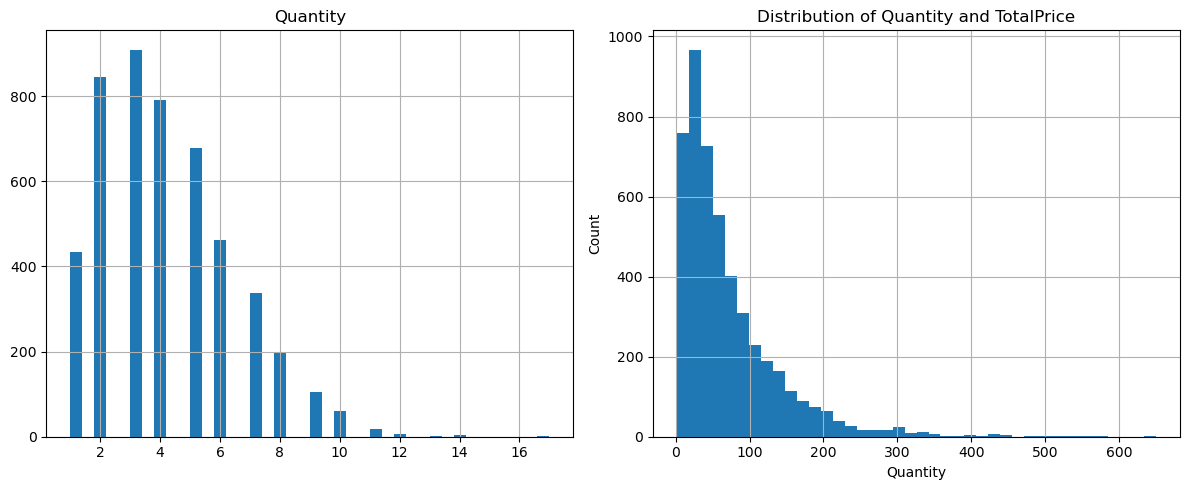

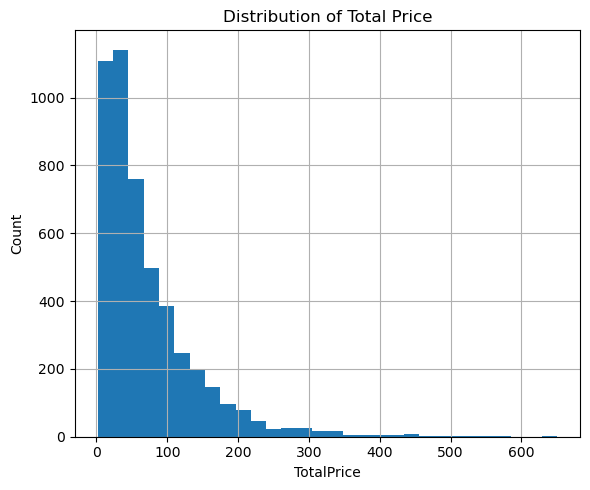

In [15]:
# TODO: ציירו histogram עבור Quantity ו-TotalPrice
dfc[["Quantity", "TotalPrice"]].hist(bins=40, figsize=(12, 5))
plt.title("Distribution of Quantity and TotalPrice")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

dfc[["TotalPrice"]].hist(bins=30, figsize=(6, 5))
plt.title("Distribution of Total Price")
plt.xlabel("TotalPrice")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
dfc["Quantity"].hist(bins=60)
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.title("Quantity Distribution")
plt.show()

dfc["TotalPrice"].hist(bins=80)
plt.xlabel("TotalPrice")
plt.ylabel("Count")
plt.title("TotalPrice Distribution")
plt.show()
```

אם יש skew חזק, קלאסטרינג ישירות על ערכים גולמיים עלול להיות נשלט על ידי outliers.

</details>

<div dir="rtl" style="text-align:right">

## 5. בניית RFM

כעת נעבור מטבלת עסקאות לטבלת לקוחות.

RFM:

- **Recency** — כמה ימים עברו מאז הקנייה האחרונה.
- **Frequency** — כמה חשבוניות ייחודיות היו ללקוח.
- **Monetary** — כמה כסף הלקוח הוציא בסך הכול.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 6 — יצירת טבלת RFM

צרו טבלה בשם `rfm` שבה כל שורה היא לקוח.

השתמשו ב:

```python
snapshot_date = dfc["InvoiceDate"].max() + pd.Timedelta(days=1)
```

וצרו את העמודות:

- `Recency`
- `Frequency`
- `Monetary`
- `TotalItems`
- `AvgBasketValue`
- `AvgItemsPerInvoice`

</div>

In [18]:
# TODO: צרו טבלת rfm
snapshot_date = dfc["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = dfc.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalItems=("Quantity", "sum")
)
rfm = rfm.reset_index()
rfm["AvaragePrice"] = rfm["Monetary"] / rfm["Frequency"]
rfm["AvarageItems"] = rfm["Monetary"] / rfm["TotalItems"]

print(rfm.head())
print(rfm.shape)

   CustomerID  Recency  Frequency  Monetary  TotalItems  AvaragePrice  \
0       10000        3          1      8.16           3      8.160000   
1       10001       69          2     77.19           5     38.595000   
2       10002      110          4     72.80           8     18.200000   
3       10003       89          1     11.32           2     11.320000   
4       10004        4         15   2110.57          86    140.704667   

   AvarageItems  
0      2.720000  
1     15.438000  
2      9.100000  
3      5.660000  
4     24.541512  
(899, 7)


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
snapshot_date = dfc["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = dfc.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalItems=("Quantity", "sum")
).reset_index()

rfm["AvgBasketValue"] = rfm["Monetary"] / rfm["Frequency"]
rfm["AvgItemsPerInvoice"] = rfm["TotalItems"] / rfm["Frequency"]

rfm.head()
```

כעת כל שורה מייצגת לקוח אחד ולא עסקה אחת.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 7 — בדיקת התפלגויות RFM

צרו Histogram עבור:

- `Recency`
- `Frequency`
- `Monetary`

</div>

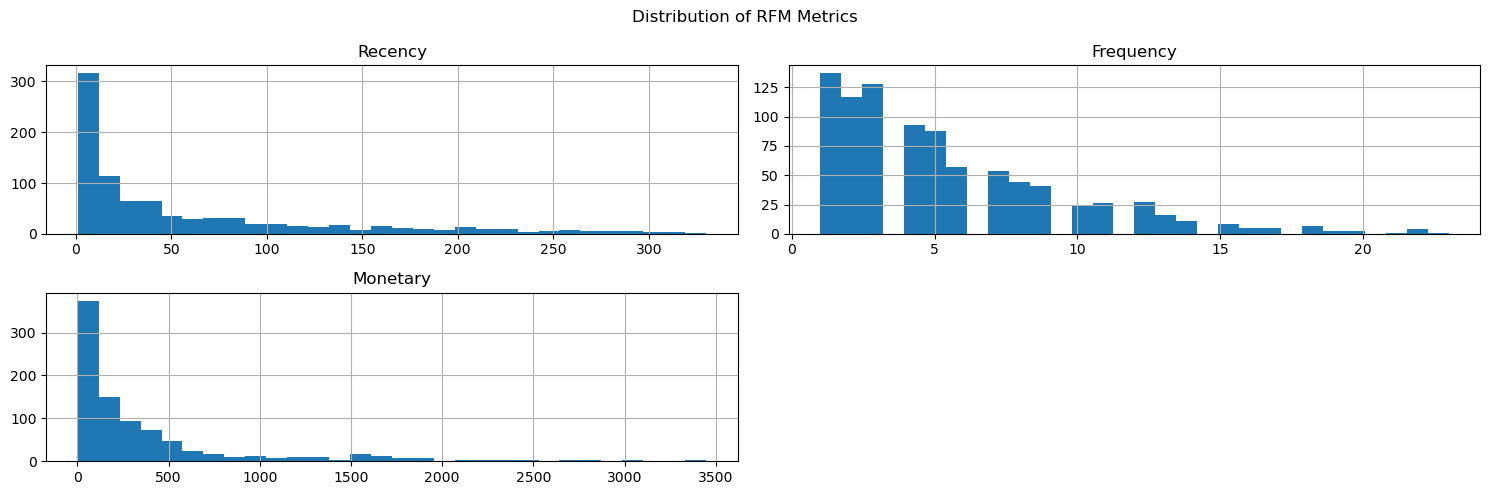

In [23]:
# TODO: ציירו התפלגויות של Recency, Frequency, Monetary
rfm[["Recency", "Frequency", "Monetary"]].hist(bins=30, figsize=(15, 5))
plt.suptitle("Distribution of RFM Metrics") 
plt.tight_layout()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
for col in ["Recency", "Frequency", "Monetary"]:
    rfm[col].hist(bins=50)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} Distribution")
    plt.show()
```

בדרך כלל `Frequency` ו־`Monetary` יהיו מאוד skewed.  
זה מצדיק שימוש ב־`log1p`.

</details>

<div dir="rtl" style="text-align:right">

## 6. הכנת מטריצת clustering

נשתמש ב־RFM הקלאסי בלבד:

```python
["Recency", "Frequency", "Monetary"]
```

נבצע:

1. `log1p` כדי לצמצם skew.
2. `StandardScaler` כדי שכל פיצ׳ר יהיה בסקאלה דומה.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 8 — log1p ו־Scaling

צרו:

- `X` — טבלת הפיצ׳רים המקורית.
- `X_log` — לאחר `np.log1p`.
- `X_scaled` — לאחר `StandardScaler`.

לאחר מכן צרו DataFrame בשם `X_scaled_df` להצגה.

</div>

In [22]:
# TODO: הכינו את X_scaled
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

x_scaled_df = pd.DataFrame(X_scaled, columns=features)
index = rfm.index
display(x_scaled_df.head())


,Recency,Frequency,Monetary
0,-1.246886,-1.530806,-1.907080
1,0.713447,-0.887633,-0.452986
2,1.029211,-0.077330,-0.492170
3,0.885573,-1.530806,-1.706099
4,-1.094054,1.767730,1.782134


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
FEATURES = ["Recency", "Frequency", "Monetary"]

X = rfm[FEATURES].copy()
X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[f"{c}_scaled" for c in FEATURES],
    index=rfm.index
)

X_scaled_df.head()
```

הערה: K-Means רואה רק את המרחבים והמרחקים אחרי הטרנספורמציה.  
כלומר preprocessing הוא חלק מהגדרת המודל.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 9 — בדיקת ההתפלגויות אחרי טרנספורמציה

ציירו Histogram של שלושת המשתנים אחרי `log1p` ו־scaling.

שאלה:

האם המשתנים עכשיו נראים דומים יותר מבחינת סקאלה?

</div>

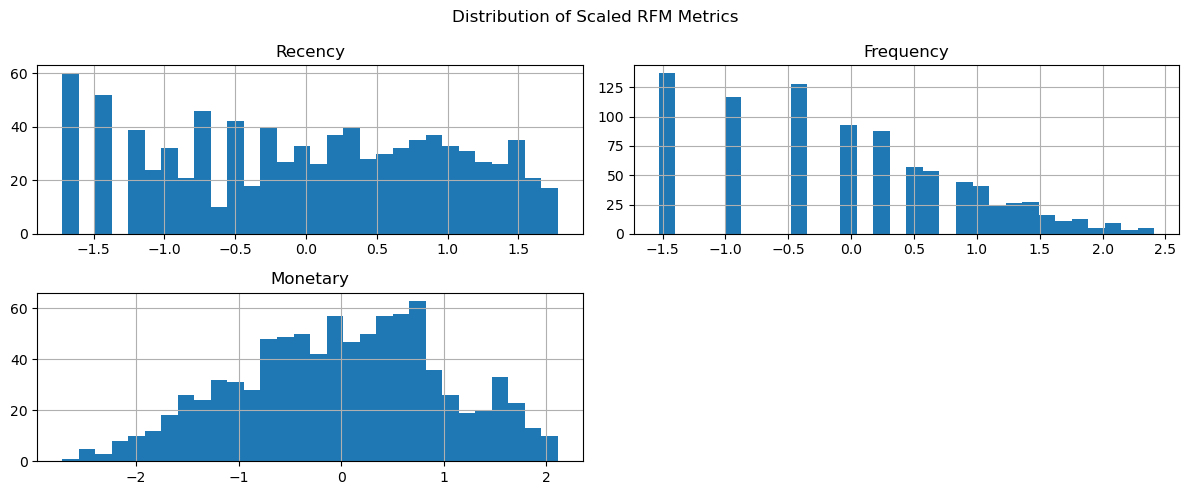

In [24]:
# TODO: ציירו histogram של X_scaled_df
x_scaled_df.hist(bins=30, figsize=(12, 5))
plt.suptitle("Distribution of Scaled RFM Metrics")  
plt.tight_layout()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
for col in X_scaled_df.columns:
    X_scaled_df[col].hist(bins=50)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} After log1p + scaling")
    plt.show()
```

לא חובה שההתפלגויות יהיו נורמליות.  
המטרה היא לצמצם השפעת זנבות ולהביא את המשתנים לסקאלה דומה.

</details>

<div dir="rtl" style="text-align:right">

## 7. בחירת מספר קלאסטרים

נבדוק כמה ערכי `k`.


- **Elbow / Inertia** — כמה קרובים הלקוחות למרכזי הקלאסטרים.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 10 — Elbow 

חשבו עבור `k=2` עד `k=8`:

- `inertia_`

וציירו  גרפים.

שאלה:

איזה k נראה סביר? למה?

</div>

k=2, Inertia=1025.70
k=3, Inertia=704.60
k=4, Inertia=524.73
k=5, Inertia=439.00
k=6, Inertia=377.77
k=7, Inertia=335.56
k=8, Inertia=300.27


c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

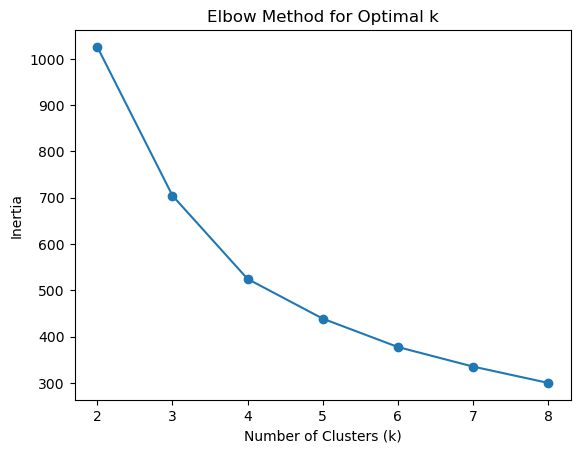

In [28]:
# TODO: חשבו inertia  עבור k=2..8
ks=range(2, 9)
inertia_values = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(x_scaled_df)
    inertia_values.append(kmeans.inertia_)

for k, inertia in zip(ks, inertia_values):
    print(f"k={k}, Inertia={inertia:.2f}")


plt.plot(ks, inertia_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")        
plt.ylabel("Inertia")
plt.xticks(ks)
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
ks = range(2, 9)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

pd.DataFrame({
    "k": list(ks),
    "inertia": inertias,
    "silhouette": silhouettes
})
```

```python
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette by k")
plt.show()
```

בחירת k אינה רק החלטה מתמטית.  
צריך גם לוודא שהקלאסטרים ניתנים להסבר עסקי.

</details>

<div dir="rtl" style="text-align:right">

## 8. אימון K-Means

נבחר `k=4` כברירת מחדל, אלא אם הגרפים שלכם מציעים בחירה אחרת.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 11 — K-Means עם k=4

אמנו מודל K-Means עם `k=4`.

הוסיפו ל־`rfm` עמודה בשם `Cluster`.

בדקו כמה לקוחות יש בכל קלאסטר.

</div>

In [29]:
# TODO: אמנו KMeans והוסיפו Cluster ל-rfm
k=4
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans.fit_predict(x_scaled_df)
rfm["Cluster"].value_counts().sort_index()



c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster
0    180
1    264
2    289
3    166
Name: count, dtype: int64

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
K = 4

kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm["Cluster"].value_counts().sort_index()
```

</details>

<div dir="rtl" style="text-align:right">

## 9. PCA להצגה דו־ממדית

K-Means רץ על 3 פיצ׳רים, אבל קשה לראות 3D.

נשתמש ב־PCA כדי להקרין את הלקוחות ל־2 ממדים לצורך ויזואליזציה בלבד.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 12 — PCA Cluster View

בצעו PCA ל־2 רכיבים וציירו scatter plot של הלקוחות לפי הקלאסטרים.

</div>

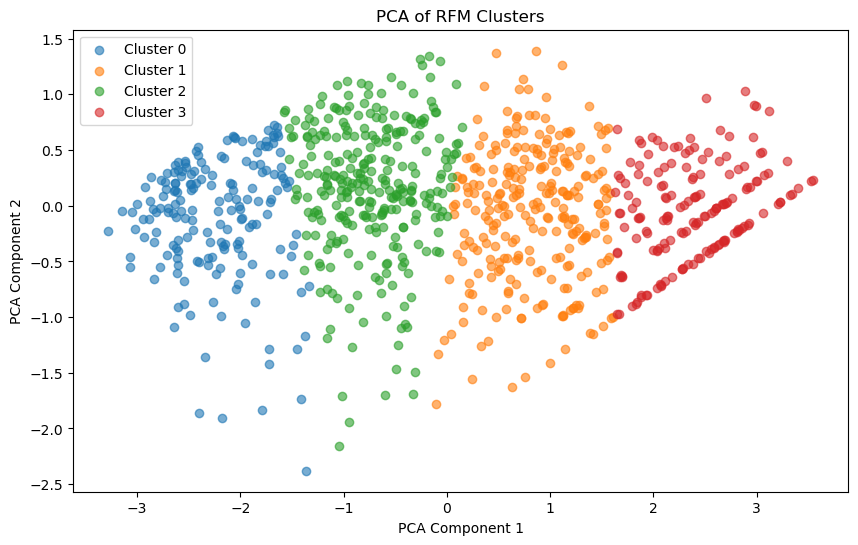

In [30]:
# TODO: PCA ל-2 רכיבים + scatter plot
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(x_scaled_df)
rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]   
plt.figure(figsize=(10, 6))
for cluster in sorted(rfm["Cluster"].unique()):
    cluster_data = rfm[rfm["Cluster"] == cluster]
    plt.scatter(cluster_data["PCA1"], cluster_data["PCA2"], label=f"Cluster {cluster}", alpha=0.6)
plt.title("PCA of RFM Clusters")
plt.xlabel("PCA Component 1")       
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

rfm["PC1"] = X_pca[:, 0]
rfm["PC2"] = X_pca[:, 1]

plt.scatter(rfm["PC1"], rfm["PC2"], c=rfm["Cluster"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
```

חשוב: PCA כאן הוא כלי ויזואלי.  
הקלאסטרים נבנו על `X_scaled`, לא על הגרף הדו־ממדי.

</details>

<div dir="rtl" style="text-align:right">

## 10. פרופיל קלאסטרים

עכשיו הופכים מספרי קלאסטרים לסיפור עסקי.

נבדוק עבור כל קלאסטר:

- כמות לקוחות
- Recency ממוצע וחציוני
- Frequency ממוצע וחציוני
- Monetary ממוצע וחציוני
- AvgBasketValue ממוצע

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 13 — Cluster Profiles

צרו טבלת פרופיל לפי `Cluster`.

לאחר מכן נסו לתת שם עסקי לכל קלאסטר, למשל:

- Champions
- Loyal Customers
- At Risk
- Low Value / New Customers

</div>

In [38]:
# TODO: צרו cluster profile
cluster_profile = rfm.groupby("Cluster").agg(
    Recency_Mean= ("Recency", "mean"),
    Frequency_Mean= ("Frequency", "mean"),
    Monetary_Mean= ("Monetary", "mean"),    
    AvaragePrice_Mean= ("AvaragePrice", "mean"),
    Count=("CustomerID", "count")
).reset_index()   
print(cluster_profile.head())


   Cluster  Recency_Mean  Frequency_Mean  Monetary_Mean  AvaragePrice_Mean  \
0        0    155.827778        1.294444      24.028278          19.314944   
1        1     14.659091        6.299242     333.239924          52.585098   
2        2     69.235294        3.217993     109.031696          35.489601   
3        3      3.198795       12.198795    1347.611627         107.140345   

   Count  
0    180  
1    264  
2    289  
3    166  


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
cluster_profile = rfm.groupby("Cluster").agg(
    customers=("CustomerID", "count"),
    recency_mean=("Recency", "mean"),
    recency_median=("Recency", "median"),
    frequency_mean=("Frequency", "mean"),
    frequency_median=("Frequency", "median"),
    monetary_mean=("Monetary", "mean"),
    monetary_median=("Monetary", "median"),
    avg_basket_mean=("AvgBasketValue", "mean")
).round(2)

cluster_profile
```

פרשנות אפשרית:

- Recency נמוך + Frequency גבוה + Monetary גבוה → לקוחות חזקים / Champions.
- Recency גבוה + Monetary/Frequency נמוכים → לקוחות חלשים או לא פעילים.
- Frequency גבוה אבל Monetary בינוני → לקוחות נאמנים אך פחות רווחיים.
- Monetary גבוה אבל Frequency נמוך → קונים גדולים אבל לא תכופים.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 14 — ויזואליזציה עסקית של הקלאסטרים

צרו bar plots של ממוצע:

- `Recency`
- `Frequency`
- `Monetary`

לפי Cluster.

שאלה:

איזו ויזואליזציה הכי עוזרת להבין את הסגמנטים?

</div>

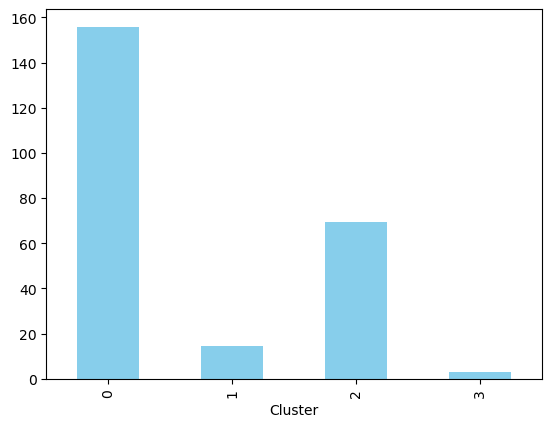

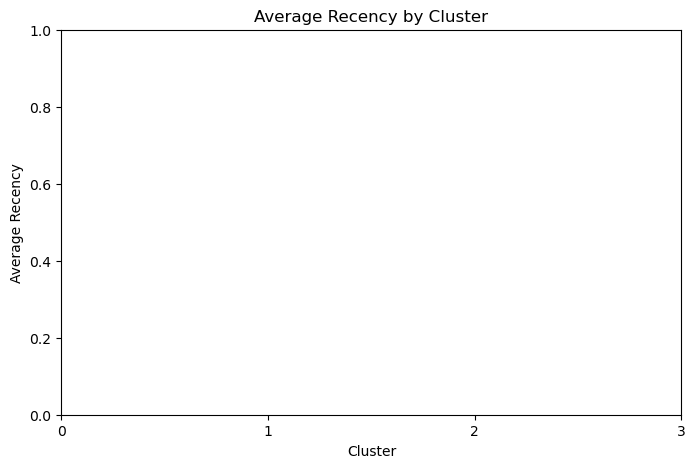

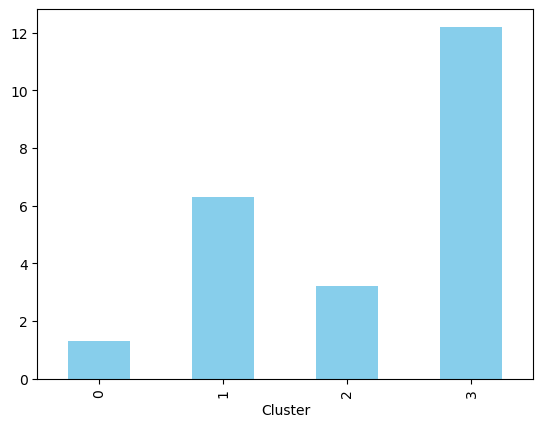

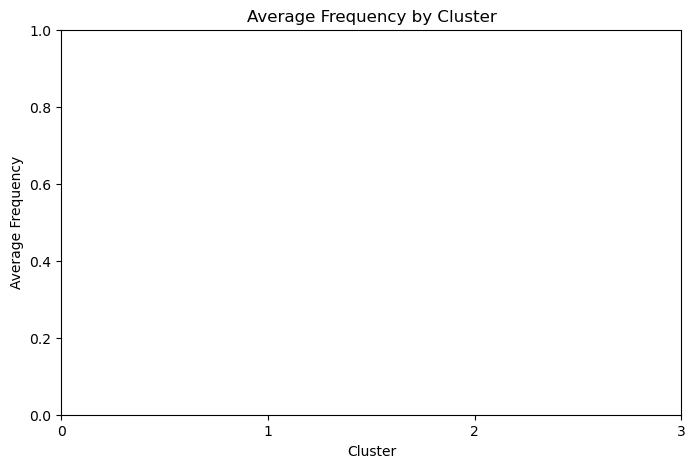

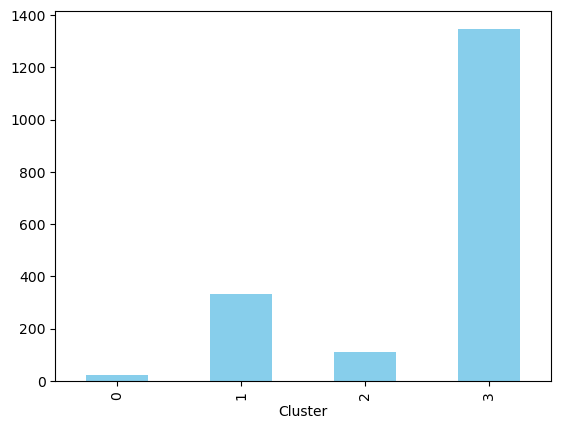

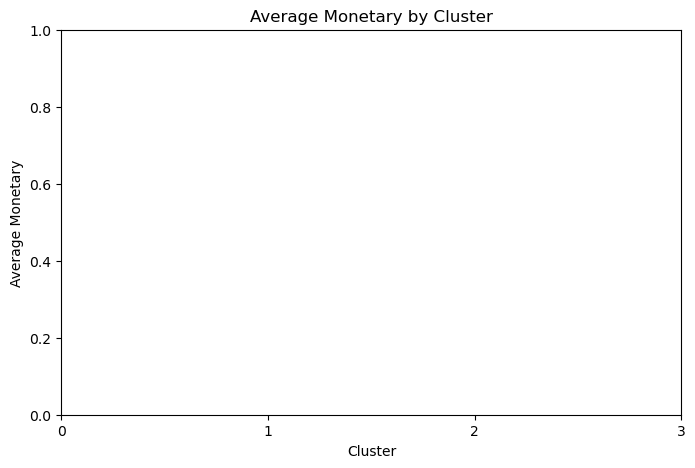

In [36]:
# TODO: bar plots לפי Cluster
for feature in ["Recency", "Frequency", "Monetary"]:
    rfm.groupby("Cluster")[feature].mean().plot(kind='bar', color='skyblue')
    plt.figure(figsize=(8, 5))
    plt.title(f"Average {feature} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(f"Average {feature}")
    plt.xticks(cluster_profile["Cluster"])
    plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
for col in ["Recency", "Frequency", "Monetary"]:
    rfm.groupby("Cluster")[col].mean().plot(kind="bar")
    plt.ylabel(f"Average {col}")
    plt.title(f"Average {col} by Cluster")
    plt.show()
```

לרוב, שילוב של טבלת profile + bar plots נותן את הפרשנות הטובה ביותר.

</details>

<div dir="rtl" style="text-align:right">

## 11. בדיקת רגישות — מה קורה בלי Scaling?

זהו תרגיל חשוב: נראה למה preprocessing משפיע על התוצאה.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 15 — השוואה לקלאסטרינג בלי Scaling

הריצו K-Means על `X_log` בלבד, בלי `StandardScaler`.

השוו:

1. גודל הקלאסטרים.
2. פרופיל הקלאסטרים.
3. האם התוצאה נראית נשלטת על ידי Monetary?

</div>

In [41]:
# TODO: KMeans על X_log בלבד והשוואה
kmeans_log = KMeans(n_clusters=k, random_state=RANDOM_STATE)

print("Scaling with")
rfm["Cluster_Log"] = kmeans_log.fit_predict(X_log)


profile_log = rfm.groupby("Cluster_Log").agg(
    Recency_Mean= ("Recency", "mean"),
    Frequency_Mean= ("Frequency", "mean"),
    Monetary_Mean= ("Monetary", "mean"),    
    AvaragePrice_Mean= ("AvaragePrice", "mean"),
    Count=("CustomerID", "count")
)

profile_log = profile_log.reset_index()
print(profile_log.head())


kmeans_no_scaling = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster_no_scaling"] = kmeans_no_scaling.fit_predict(X_log)

print("With scaling:")
display(rfm["Cluster"].value_counts().sort_index())

print("Without scaling:")
display(rfm["Cluster_no_scaling"].value_counts().sort_index())

profile_no_scaling = rfm.groupby("Cluster_no_scaling").agg(
    customers=("CustomerID", "count"),
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean")
).round(2)

print(profile_no_scaling)

Scaling with
   Cluster_Log  Recency_Mean  Frequency_Mean  Monetary_Mean  \
0            0    156.386364        1.369318      21.662955   
1            1     14.973684        6.082707     313.222594   
2            2     74.459854        3.222628     111.448686   
3            3      3.005464       11.524590    1255.996120   

   AvaragePrice_Mean  Count  
0          16.516562    176  
1          51.064652    266  
2          36.312310    274  
3         103.613456    183  
With scaling:


c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\beler\.conda\envs\course-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster
0    180
1    264
2    289
3    166
Name: count, dtype: int64

Without scaling:


Cluster_no_scaling
0    183
1    276
2    169
3    271
Name: count, dtype: int64

                    customers  recency_mean  frequency_mean  monetary_mean
Cluster_no_scaling                                                        
0                         183          3.01           11.52        1256.00
1                         276         79.21            3.19         109.95
2                         169        153.54            1.33          19.76
3                         271         15.13            6.04         309.89


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
kmeans_no_scaling = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster_no_scaling"] = kmeans_no_scaling.fit_predict(X_log)

print("With scaling:")
display(rfm["Cluster"].value_counts().sort_index())

print("Without scaling:")
display(rfm["Cluster_no_scaling"].value_counts().sort_index())

profile_no_scaling = rfm.groupby("Cluster_no_scaling").agg(
    customers=("CustomerID", "count"),
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean")
).round(2)

profile_no_scaling
```

כאשר לא מבצעים scaling, פיצ׳רים עם סקאלה גדולה יותר יכולים לשלוט במרחקים ולכן גם בקלאסטרים.

</details>